## Dự đoán viên phổi qua ảnh chụp X-quang (Giữa kỳ)
Nhóm: Trương Văn Diệu

MSV: 23017208

Giảng viên: TS. Lê Minh Huy

Lớp: Học sâu(N01)

Việc đọc ảnh và tiền xử lý dữ liệu được thực hiện bằng các thư viện xử lý ảnh thông dụng. Tuy nhiên, toàn bộ mô hình học sâu, bao gồm quá trình lan truyền xuôi (forward propagation), tính hàm mất mát (loss), lan truyền ngược (backpropagation) và tối ưu tham số, đều được cài đặt hoàn toàn từ đầu (from scratch) bằng Python, không sử dụng bất kỳ thư viện học sâu nào.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Datasets/X-ray.zip"
extract_to = "/content/X-ray"

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Dataset extracted to:", extract_to)

Dataset extracted to: /content/X-ray


In [ ]:
# import thư viện để đọc ảnh trong dataset
import os, glob, random
import cv2
import numpy as np

In [ ]:
# Đường dẫn dataset
data_dir = os.path.join(extract_to, 'X-ray')
train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

print("Train:", train_dir)
print("Val  :", val_dir)
print(
"Test :", test_dir
)

# class names
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", class_names)

# map label: NORMAL->0, PNEUMONIA->1 (theo alphabet)
class_to_idx = {c:i for i,c in enumerate(class_names)}
print("class_to_idx:", class_to_idx)

Train: /content/X-ray/X-ray/train
Val  : /content/X-ray/X-ray/val
Test : /content/X-ray/X-ray/test
Classes: ['NORMAL', 'PNEUMONIA']
class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
# Load ảnh -> vector (dùng cv2 + numpy), output ra python list
# Ảnh sẽ resize về size nhỏ để train được
IMG_W, IMG_H = 32, 32
MAX_PER_CLASS = None

def load_split_as_lists(split_dir, max_per_class=None):
    X_list = []
    y_list = []

    for cls in class_names:
        cls_dir = os.path.join(split_dir, cls)
        files = sorted(glob.glob(os.path.join(cls_dir, "*")))
        if max_per_class is not None:
            files = files[:max_per_class]

        label = class_to_idx[cls]
        for fp in files:
            img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)

            # normalize [0,1] và flatten
            vec = (img.astype(np.float32) / 255.0).reshape(-1)

            # chuyển sang python list để model không dùng numpy
            X_list.append(vec.tolist())
            y_list.append(label)

    return X_list, y_list

X_train, y_train = load_split_as_lists(train_dir, MAX_PER_CLASS)
X_val,   y_val   = load_split_as_lists(val_dir,   MAX_PER_CLASS)
X_test,  y_test  = load_split_as_lists(test_dir,  MAX_PER_CLASS)

print("Train samples:", len(X_train))
print("Val samples  :", len(X_val))
print("Test samples :", len(X_test))
print("Feature dim  :", len(X_train[0]) if X_train else 0)

Train samples: 5216
Val samples  : 16
Test samples : 624
Feature dim  : 1024


In [ ]:
# Shuffle
def shuffle_in_unison(X, y, seed=123):
    rnd = random.Random(seed)
    idx = list(range(len(X)))
    rnd.shuffle(idx)
    X2 = [X[i] for i in idx]
    y2 = [y[i] for i in idx]
    return X2, y2

X_train, y_train = shuffle_in_unison(X_train, y_train, seed=123)
X_val, y_val     = shuffle_in_unison(X_val, y_val, seed=123)

LIMIT_TRAIN = None
LIMIT_VAL   = None

if LIMIT_TRAIN is not None:
    X_train, y_train = X_train[:LIMIT_TRAIN], y_train[:LIMIT_TRAIN]
if LIMIT_VAL is not None:
    X_val, y_val = X_val[:LIMIT_VAL], y_val[:LIMIT_VAL]

print("After limit - Train:", len(X_train), "Val:", len(X_val))

After limit - Train: 5216 Val: 16


In [ ]:
# Hàm toán học, activation (chỉ dùng Python, math là stdlib)
import math

def relu(x):
    return x if x > 0.0 else 0.0

def relu_grad(x):
    return 1.0 if x > 0.0 else 0.0

def softmax(logits):
    # logits: list[float]
    m = max(logits)
    exps = [math.exp(z - m) for z in logits]
    s = sum(exps)
    return [e / s for e in exps]

def one_hot(y, num_classes):
    v = [0.0] * num_classes
    v[y] = 1.0
    return v

def cross_entropy(probs, y_onehot):
    # - sum(y * log(p))
    eps = 1e-12
    return -sum(y_onehot[i] * math.log(probs[i] + eps) for i in range(len(probs)))

In [ ]:
# Dense layer from scratch (forward/backward)
def init_weights(out_dim, in_dim, rng):
    # Xavier-ish small init
    limit = math.sqrt(6.0 / (in_dim + out_dim))
    W = [[rng.uniform(-limit, limit) for _ in range(in_dim)] for _ in range(out_dim)]
    b = [0.0 for _ in range(out_dim)]
    return W, b

def matvec(W, x, b):
    # W: out_dim x in_dim, x: in_dim
    out = []
    for i in range(len(W)):
        s = b[i]
        Wi = W[i]
        for j in range(len(x)):
            s += Wi[j] * x[j]
        out.append(s)
    return out

def dense_backward(W, x, grad_out):
    # grad_out: dL/dz (out_dim)
    # returns grad_x, grad_W, grad_b
    out_dim = len(W)
    in_dim = len(W[0])

    grad_x = [0.0] * in_dim
    grad_W = [[0.0] * in_dim for _ in range(out_dim)]
    grad_b = [0.0] * out_dim

    for i in range(out_dim):
        gi = grad_out[i]
        grad_b[i] += gi
        Wi = W[i]
        for j in range(in_dim):
            grad_W[i][j] += gi * x[j]
            grad_x[j] += Wi[j] * gi

    return grad_x, grad_W, grad_b

def sgd_update(W, b, gW, gb, lr, batch_size):
    # update in-place: W -= lr * gW/batch
    out_dim = len(W)
    in_dim = len(W[0])
    scale = lr / batch_size
    for i in range(out_dim):
        b[i] -= scale * gb[i]
        for j in range(in_dim):
            W[i][j] -= scale * gW[i][j]

In [ ]:
# Khai báo MLP 5 layer (4 hidden + 1 output)
# Input dim:
D = len(X_train[0])
NUM_CLASSES = len(class_names)

# hidden sizes
H1, H2, H3, H4 = 256, 128, 64, 32

rng = random.Random(42)

W1, b1 = init_weights(H1, D, rng)
W2, b2 = init_weights(H2, H1, rng)
W3, b3 = init_weights(H3, H2, rng)
W4, b4 = init_weights(H4, H3, rng)
W5, b5 = init_weights(NUM_CLASSES, H4, rng)

def forward(x):
    # trả về (cache, probs)
    z1 = matvec(W1, x, b1); a1 = [relu(v) for v in z1]
    z2 = matvec(W2, a1, b2); a2 = [relu(v) for v in z2]
    z3 = matvec(W3, a2, b3); a3 = [relu(v) for v in z3]
    z4 = matvec(W4, a3, b4); a4 = [relu(v) for v in z4]
    z5 = matvec(W5, a4, b5)
    probs = softmax(z5)
    cache = (x, z1, a1, z2, a2, z3, a3, z4, a4, z5, probs)
    return cache, probs

In [ ]:
# Backprop & Train
def zero_grads_like(W, b):
    gW = [[0.0] * len(W[0]) for _ in range(len(W))]
    gb = [0.0] * len(b)
    return gW, gb

def add_grads(gW, gb, dW, db):
    for i in range(len(gW)):
        gb[i] += db[i]
        row = gW[i]
        drow = dW[i]
        for j in range(len(row)):
            row[j] += drow[j]

def train_epoch(X, y, lr=0.05, batch_size=16):
    # shuffle
    Xs, ys = shuffle_in_unison(X, y, seed=random.randint(0, 10**9))

    total_loss = 0.0
    correct = 0
    n = len(Xs)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        bs = end - start

        gW1, gb1 = zero_grads_like(W1, b1)
        gW2, gb2 = zero_grads_like(W2, b2)
        gW3, gb3 = zero_grads_like(W3, b3)
        gW4, gb4 = zero_grads_like(W4, b4)
        gW5, gb5 = zero_grads_like(W5, b5)

        for i in range(start, end):
            x = Xs[i]
            yi = ys[i]
            yoh = one_hot(yi, NUM_CLASSES)

            cache, probs = forward(x)
            (x0, z1, a1, z2, a2, z3, a3, z4, a4, z5, probs) = cache

            loss = cross_entropy(probs, yoh)
            total_loss += loss

            pred = max(range(NUM_CLASSES), key=lambda k: probs[k])
            if pred == yi:
                correct += 1

            # gradient for softmax + cross entropy: dL/dz = probs - y
            dz5 = [probs[k] - yoh[k] for k in range(NUM_CLASSES)]

            # layer 5
            da4, dW5, db5 = dense_backward(W5, a4, dz5)

            # layer 4 (ReLU)
            dz4 = [da4[j] * relu_grad(z4[j]) for j in range(len(z4))]
            da3, dW4, db4 = dense_backward(W4, a3, dz4)

            # layer 3
            dz3 = [da3[j] * relu_grad(z3[j]) for j in range(len(z3))]
            da2, dW3, db3 = dense_backward(W3, a2, dz3)

            # layer 2
            dz2 = [da2[j] * relu_grad(z2[j]) for j in range(len(z2))]
            da1, dW2, db2 = dense_backward(W2, a1, dz2)

            # layer 1
            dz1 = [da1[j] * relu_grad(z1[j]) for j in range(len(z1))]
            _, dW1, db1_ = dense_backward(W1, x0, dz1)

            # cộng dồn grads
            add_grads(gW5, gb5, dW5, db5)
            add_grads(gW4, gb4, dW4, db4)
            add_grads(gW3, gb3, dW3, db3)
            add_grads(gW2, gb2, dW2, db2)
            add_grads(gW1, gb1, dW1, db1_)

        # update SGD theo batch
        sgd_update(W5, b5, gW5, gb5, lr, bs)
        sgd_update(W4, b4, gW4, gb4, lr, bs)
        sgd_update(W3, b3, gW3, gb3, lr, bs)
        sgd_update(W2, b2, gW2, gb2, lr, bs)
        sgd_update(W1, b1, gW1, gb1, lr, bs)

    return total_loss / n, correct / n

def evaluate(X, y):
    correct = 0
    for i in range(len(X)):
        _, probs = forward(X[i])
        pred = max(range(NUM_CLASSES), key=lambda k: probs[k])
        if pred == y[i]:
            correct += 1
    return correct / len(X)

EPOCHS = 5
LR = 0.05
BATCH = 16

for ep in range(1, EPOCHS + 1):
    loss, acc = train_epoch(X_train, y_train, lr=LR, batch_size=BATCH)
    val_acc = evaluate(X_val, y_val) if len(X_val) > 0 else 0.0
    print(f"Epoch {ep}/{EPOCHS} - loss: {loss:.4f} - train_acc: {acc:.4f} - val_acc: {val_acc:.4f}")

Epoch 1/5 - loss: 0.4475 - train_acc: 0.7899 - val_acc: 0.8125
Epoch 2/5 - loss: 0.2761 - train_acc: 0.8886 - val_acc: 0.8125
Epoch 3/5 - loss: 0.2075 - train_acc: 0.9191 - val_acc: 0.8125
Epoch 4/5 - loss: 0.1784 - train_acc: 0.9319 - val_acc: 0.8750
Epoch 5/5 - loss: 0.1679 - train_acc: 0.9337 - val_acc: 0.8125


In [ ]:
# Confusion matrix, Precision/Recall/F1
def confusion_matrix(y_true, y_pred, num_classes):
    cm = [[0 for _ in range(num_classes)] for _ in range(num_classes)]
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    return cm

def predict_labels(X):
    preds = []
    for i in range(len(X)):
        _, probs = forward(X[i])
        pred = max(range(NUM_CLASSES), key=lambda k: probs[k])
        preds.append(pred)
    return preds

def precision_recall_f1(cm, cls):
    tp = cm[cls][cls]
    fp = sum(cm[r][cls] for r in range(len(cm)) if r != cls)
    fn = sum(cm[cls][c] for c in range(len(cm)) if c != cls)

    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    return prec, rec, f1

y_pred = predict_labels(X_test)
test_acc = sum(1 for a,b in zip(y_test, y_pred) if a==b) / len(y_test)
print("Test accuracy:", test_acc)

cm = confusion_matrix(y_test, y_pred, NUM_CLASSES)
print("\nConfusion Matrix (rows=true, cols=pred):")
for r in range(NUM_CLASSES):
    print(cm[r])

print("\nPer-class metrics:")
for i, name in enumerate(class_names):
    p, r, f1 = precision_recall_f1(cm, i)
    print(f"{name:10s}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}")

Test accuracy: 0.7756410256410257

Confusion Matrix (rows=true, cols=pred):
[102, 132]
[8, 382]

Per-class metrics:
NORMAL      Precision=0.9273  Recall=0.4359  F1=0.5930
PNEUMONIA   Precision=0.7432  Recall=0.9795  F1=0.8451


In [ ]:
# Lưu weights ra file
def save_matrix(f, M, name):
    f.write(name + "\n")
    f.write(f"{len(M)} {len(M[0])}\n")
    for row in M:
        f.write(" ".join(str(v) for v in row) + "\n")

def save_vector(f, v, name):
    f.write(name + "\n")
    f.write(f"{len(v)}\n")
    f.write(" ".join(str(x) for x in v) + "\n")

save_path = "/content/mlp_scratch_weights.txt"
with open(save_path, "w", encoding="utf-8") as f:
    save_matrix(f, W1, "W1"); save_vector(f, b1, "b1")
    save_matrix(f, W2, "W2"); save_vector(f, b2, "b2")
    save_matrix(f, W3, "W3"); save_vector(f, b3, "b3")
    save_matrix(f, W4, "W4"); save_vector(f, b4, "b4")
    save_matrix(f, W5, "W5"); save_vector(f, b5, "b5")

print("Saved weights to:", save_path)

Saved weights to: /content/mlp_scratch_weights.txt


In [ ]:
# Load weights từ file .txt

def read_nonempty_line(f):
    line = f.readline()
    while line and line.strip() == "":
        line = f.readline()
    return line

def load_matrix(f):
    name = read_nonempty_line(f).strip()
    dims = read_nonempty_line(f).strip().split()
    r, c = int(dims[0]), int(dims[1])
    M = []
    for _ in range(r):
        row = read_nonempty_line(f).strip().split()
        M.append([float(x) for x in row])
    return name, M

def load_vector(f):
    name = read_nonempty_line(f).strip()
    n = int(read_nonempty_line(f).strip())
    vals = read_nonempty_line(f).strip().split()
    v = [float(x) for x in vals]
    if len(v) != n:
        raise Exception(f"Vector {name} length mismatch: expect {n}, got {len(v)}")
    return name, v

def load_weights_txt(path):
    params = {}
    with open(path, "r", encoding="utf-8") as f:
        # W1 b1 W2 b2 W3 b3 W4 b4 W5 b5
        for _ in range(5):
            nW, W = load_matrix(f); params[nW] = W
            nb, b = load_vector(f); params[nb] = b
    return params

params = load_weights_txt(save_path)

# gán lại vào model
W1, b1 = params["W1"], params["b1"]
W2, b2 = params["W2"], params["b2"]
W3, b3 = params["W3"], params["b3"]
W4, b4 = params["W4"], params["b4"]
W5, b5 = params["W5"], params["b5"]

print("Loaded weights OK from:", save_path)
print("W1 shape:", len(W1), "x", len(W1[0]))
print("W5 shape:", len(W5), "x", len(W5[0]))


Loaded weights OK from: /content/mlp_scratch_weights.txt
W1 shape: 256 x 1024
W5 shape: 2 x 32


In [ ]:
# Đánh giá lại mô hình sau khi load
# dùng lại các hàm: forward(), predict_labels(), confusion_matrix(), precision_recall_f1()

y_pred = predict_labels(X_test)
test_acc = sum(1 for a,b in zip(y_test, y_pred) if a==b) / len(y_test)
print("Test accuracy (loaded):", test_acc)

cm = confusion_matrix(y_test, y_pred, NUM_CLASSES)
print("\nConfusion Matrix (rows=true, cols=pred):")
for r in range(NUM_CLASSES):
    print(cm[r])

print("\nPer-class metrics:")
for i, name in enumerate(class_names):
    p, r, f1 = precision_recall_f1(cm, i)
    print(f"{name:10s}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}")

Test accuracy (loaded): 0.7756410256410257

Confusion Matrix (rows=true, cols=pred):
[102, 132]
[8, 382]

Per-class metrics:
NORMAL      Precision=0.9273  Recall=0.4359  F1=0.5930
PNEUMONIA   Precision=0.7432  Recall=0.9795  F1=0.8451


Demo image: /content/X-ray/X-ray/test/PNEUMONIA/person146_bacteria_703.jpeg
Predicted: PNEUMONIA
Probabilities: {'NORMAL': 0.009, 'PNEUMONIA': 0.991}


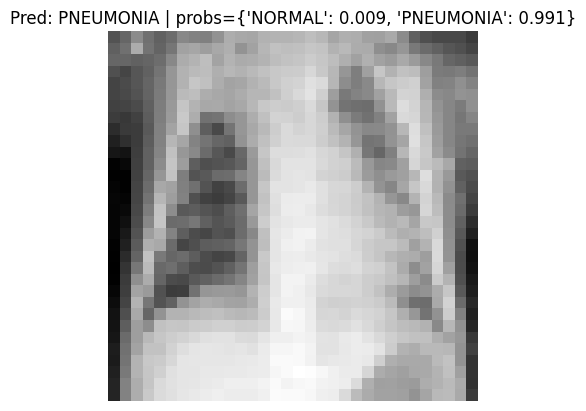

In [ ]:
# Demo predict 1 ảnh bất kỳ
def preprocess_one_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise Exception("Cannot read image: " + path)
    img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    vec = (img.astype(np.float32) / 255.0).reshape(-1).tolist()
    return vec, img

def predict_proba_one(vec):
    _, probs = forward(vec)
    return probs

# Chọn 1 ảnh demo từ test
demo_candidates = []
for cls in class_names:
    demo_candidates += glob.glob(os.path.join(test_dir, cls, "*"))

demo_path = random.choice(demo_candidates)
vec, img = preprocess_one_image(demo_path)
probs = predict_proba_one(vec)
pred_idx = max(range(NUM_CLASSES), key=lambda k: probs[k])

print("Demo image:", demo_path)
print("Predicted:", class_names[pred_idx])
print("Probabilities:", {class_names[i]: round(probs[i], 4) for i in range(NUM_CLASSES)})

# Hiển thị ảnh demo (Jupyter/Colab)
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(img, cmap="gray")
plt.title(f"Pred: {class_names[pred_idx]} | probs={ {class_names[i]: round(probs[i],3) for i in range(NUM_CLASSES)} }")
plt.axis("off")
plt.show()

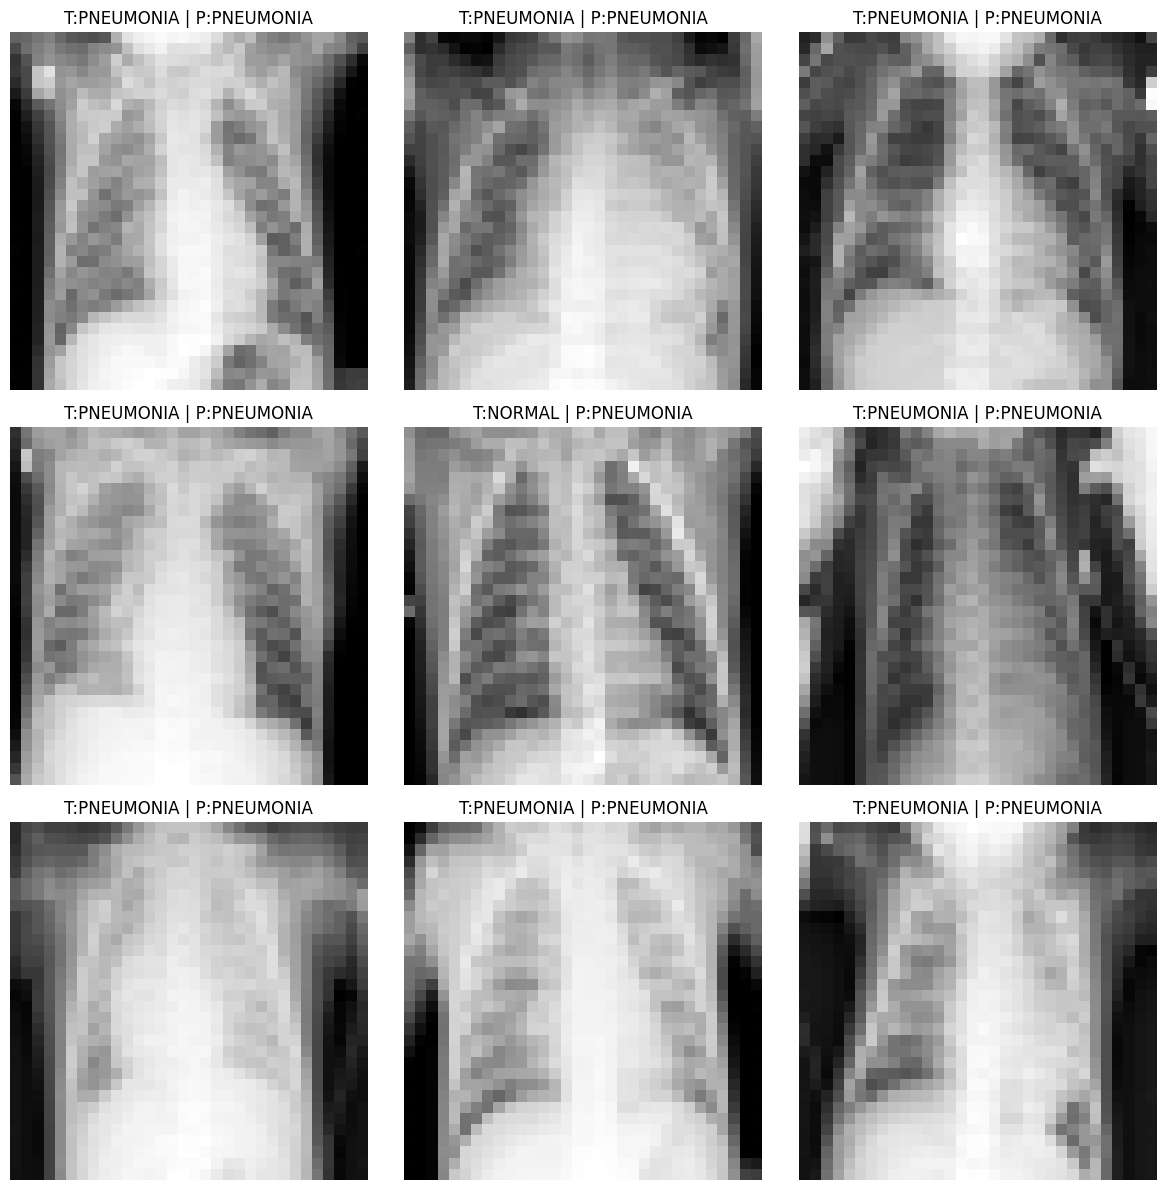

In [ ]:
# Demo 9 ảnh
def get_demo_paths(n=9):
    paths = []
    for cls in class_names:
        paths += glob.glob(os.path.join(test_dir, cls, "*"))
    random.shuffle(paths)
    return paths[:n]

demo_paths = get_demo_paths(9)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 12))

for i, p in enumerate(demo_paths, start=1):
    vec, img = preprocess_one_image(p)
    probs = predict_proba_one(vec)
    pred_idx = max(range(NUM_CLASSES), key=lambda k: probs[k])

    # lấy true label từ folder
    true_cls = os.path.basename(os.path.dirname(p))

    plt.subplot(3, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(f"T:{true_cls} | P:{class_names[pred_idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()